In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

random_state = 42

In [2]:
mnist = fetch_openml("mnist_784")

digits = datasets.load_digits()

n_samples = len(digits["images"])
X, Y = digits["images"].reshape(n_samples, -1), digits["target"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.7, random_state=random_state
)

---

Число соседей в модели kNN является необучаемым параметром т.е. гиперпараметром который выставляется вручную.

Постройте график зависимости точности (`accuracy_score`) предсказания kNN от значения $k$ (от 1 до 20) для обучающей и тестовой выборок.

In [3]:
ks = range(1, 21)
accuracies_test_l2 = []
accuracies_train_l2 = []

for k in range (1, 21):
    model = KNeighborsClassifier(n_neighbors=k, algorithm="brute")
    model.fit(X_train, Y_train)

    Y_pred_test = model.predict(X_test)
    Y_pred_train = model.predict(X_train)

    score_test = accuracy_score(Y_test, Y_pred_test)
    score_train = accuracy_score(Y_train, Y_pred_train)

    accuracies_test_l2.append(score_test)
    accuracies_train_l2.append(score_train)

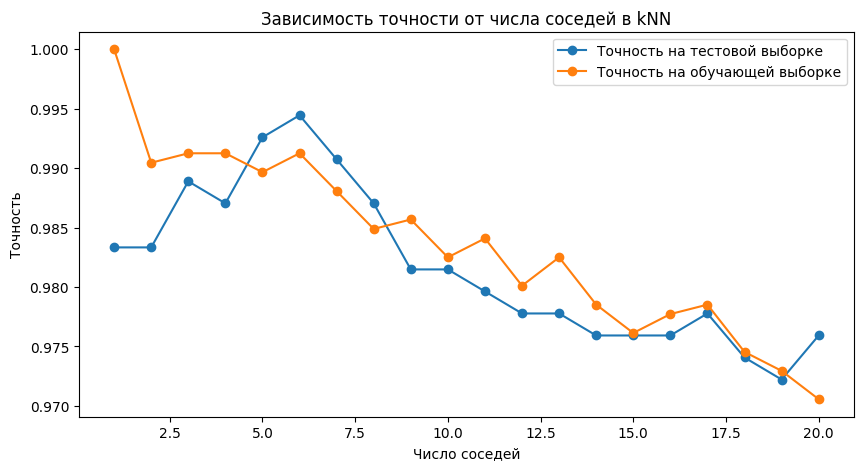

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(ks, accuracies_test_l2, label="Точность на тестовой выборке", marker="o")
plt.plot(ks, accuracies_train_l2, label="Точность на обучающей выборке", marker="o")

plt.xlabel("Число соседей")
plt.ylabel("Точность")
plt.title("Зависимость точности от числа соседей в kNN")

plt.legend()
plt.show()


> Почему при $k = 1$ на тренировочной выборке метрика качества составляет 100%.

**Ваш ответ:** Когда $k = 1$, берется только один ближайший сосед. Для обучающей выборки ближайший сосед - сама точка. Поэтому будет полное совпадение с предсказания значения и реального значения.

Помимо числа соседей гиперпараметром модели также является *метрика расстояния* между объектами.  

По умолчанию используется *Евклидова метрика* ($L_2$), иногда в kNN имеет смысл использовать другие метрики, например *метрику Манхэттена* ($L_1$). Выбор одной из них зависит от особенностей задачи и данных.

Проведите аналогичный эксперимент используя в качестве гиперпараметра $L_1$-метрику.

In [5]:
accuracies_test_l1 = []
accuracies_train_l1 = []

for k in range (1, 21):
    model = KNeighborsClassifier(n_neighbors=k, algorithm="brute", metric="manhattan")
    model.fit(X_train, Y_train)

    Y_pred_test = model.predict(X_test)
    Y_pred_train = model.predict(X_train)

    score_test = accuracy_score(Y_test, Y_pred_test)
    score_train = accuracy_score(Y_train, Y_pred_train)

    accuracies_test_l1.append(score_test)
    accuracies_train_l1.append(score_train)

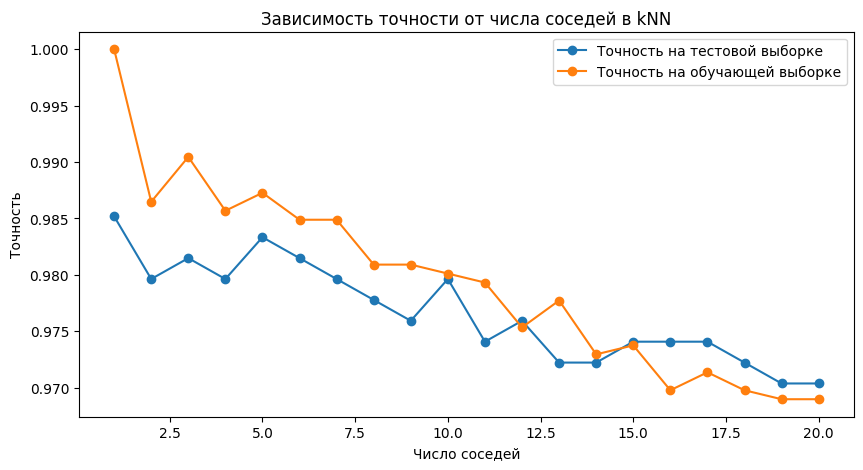

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(ks, accuracies_test_l1, label="Точность на тестовой выборке", marker="o")
plt.plot(ks, accuracies_train_l1, label="Точность на обучающей выборке", marker="o")

plt.xlabel("Число соседей")
plt.ylabel("Точность")
plt.title("Зависимость точности от числа соседей в kNN")

plt.legend()
plt.show()

> Как вы думаете почему смена метрики так сильно повлияла на характер кривых?

**Ваш ответ:** При смене метрики очень меняются блжайшие соседи. При обычной метрики если от точки x строить ГМТ точек на расстоянии y, получится круг, а при метрике L1 получается квадрат. Поэтому при разных метриках получаются разные множиства ближайших соседей, ну и как следствие - разные предсказания. 

Я построила все на одном графике, чтобы было удобнее сравнивать

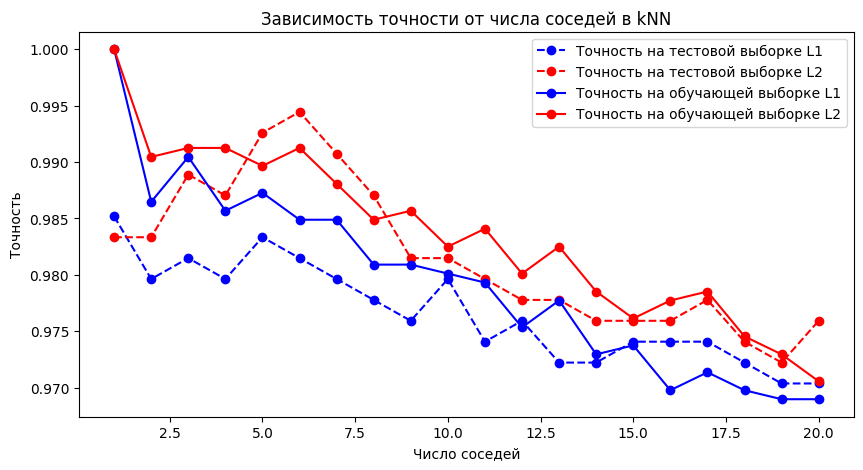

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(ks, accuracies_test_l1, linestyle='--', label="Точность на тестовой выборке L1", marker="o", color = 'b')
plt.plot(ks, accuracies_test_l2, linestyle='--', label="Точность на тестовой выборке L2", marker="o",  color = 'r')

plt.plot(ks, accuracies_train_l1, label="Точность на обучающей выборке L1", marker="o",  color = 'b')
plt.plot(ks, accuracies_train_l2, label="Точность на обучающей выборке L2", marker="o",  color = 'r')

plt.xlabel("Число соседей")
plt.ylabel("Точность")
plt.title("Зависимость точности от числа соседей в kNN")

plt.legend()
plt.show()

**Выводы:**
1. Если смотреть на обе тестовые выборки, то есть некая тенденция сначала к росту точности при увеличении числа соседей, потом  падению точности. В ноутбуке с занятия этот эффект был объяснен.
2. На обучающих выборках точность скорее просто убывает, а не сначала растет, а потом убывает. Мне кажется на маленьких k теряется значимость самой точки в предсказании, поэтому на маленьких k происходит падение точности. А на более больших k, где начинается убывание у тестовой точности для тестовой выборки причина в том, что теряется локальная информация.
3. В графиках есть общие тенденции к возрастанию или убыванию, но они довольно хаотичны.  В целом при k до 10 точность меняется примерно в пределах 1-1,5%, а при k до 20 в пределах 2-3%. Мне кажется, так как данных не очень много (в районе 1200 записей в обучающей выбоке), некоторые эффекты можно объяснить тем, что данных было недостаточно и возникли "флуктуации".
4. Для данного примера метрика L2 дает бОльшую точность чем метрика L1.  Для этой задачи лучше использовать квадратичную метрику. Это как-то связано с тем, как метрики ищут ближайших соседей, но я не могу придумать объяснения :-(.
5. Для конкретной задачи из двух разобранных метрик стоит выбрать L2 и k=6.

**Глобальные выводы для kNN:**
1. Нужно выбирать число ближайших соседей, дающий максмально точный результат для определенной задачи. Для этого можно сравнить несколько на относительно небольшом наборе данных, чтобы работало не слишкосм долго.
2. Нужно выбрать правильную метрику для задачи. Разные метрики по-разному выбирают ближайших соседей, поэтому разные метрики дают разные точности.

---

Титаник был крупнейшим пассажирским судном в 1912—1913 годах. Во время первого рейса затонул в северной Атлантике, столкнувшись с айсбергом в ночь с 14 на 15 апреля 1912 года, при этом погибло 1502 из 2224 пассажиров и членов экипажа. Данные о пассажирах были собраны в таблицы, которые можно скачать с <a href="https://www.kaggle.com/c/titanic/data" target="_blank">Kaggle</a>. Эти данные часто используются в качестве обучающих в анализе данных.


Загрузите данные с помощью `pandas`.

In [137]:
titanic = pd.read_csv("titanic/train.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


В данной задаче мы будем работать со следующими признаками
>
> * `Pclass` — класс билета (1 = первый класс, 2 = второй класс, 3 = третий класс);
>
> * `Age` — возраст пассажира;
>
> * `SibSp` — количество братьев, сестер или супругов на борту;
>
> * `Parch` — количество родителей или детей на борту;
>
> * `Fare` — стоимость билета.
>

In [138]:
features_columns = ["Pclass", "Age", "Sex", "SibSp", "Parch", "Fare"]
target_column = "Survived"  # Целевой признак

X, Y = titanic[features_columns], titanic[target_column] # на самом деле сделаю это позже
titanic = titanic[[target_column] + features_columns]

titanic.head()

,Survived,Pclass,Age,Sex,SibSp,Parch,Fare
0,0,3,22.0,male,1,0,7.2500
1,1,1,38.0,female,1,0,71.2833
2,1,3,26.0,female,0,0,7.9250
3,1,1,35.0,female,1,0,53.1000
4,0,3,35.0,male,0,0,8.0500


В данных могут присутствовать пропуски. Пока что мы не умеем с ними работать, так что исключим из данных.

In [ ]:
miss_rows = titanic.isna().any(axis=1).sum()
print(miss_rows)

177


In [140]:
titanic_clean = titanic.dropna()

Разделите данные по строкам на две части случайным образом в соотношении 7:3.

In [141]:
train_data, test_data = train_test_split(titanic_clean, test_size=0.3, random_state=random_state)

X_train, Y_train = train_data[features_columns], train_data[target_column]
X_test, Y_test = test_data[features_columns], test_data[target_column]


#### 1. Исследование


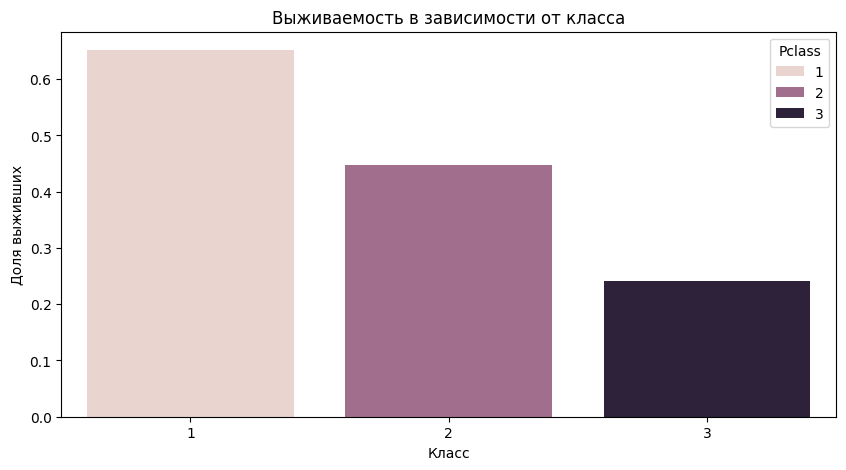

In [142]:
plt.figure(figsize=(10, 5))

sns.barplot(x="Pclass", y="Survived", data=train_data, errorbar=None, hue="Pclass")

plt.title("Выживаемость в зависимости от класса")
plt.xlabel("Класс")
plt.ylabel("Доля выживших")

plt.show()

Доля выживших довольно сильно зависит от класса. Можно считать, что есть обратная зависимость.

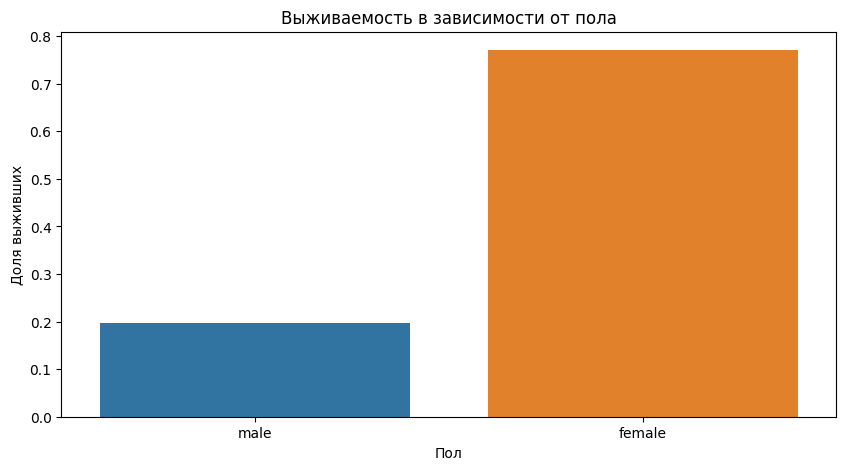

In [143]:
plt.figure(figsize=(10, 5))

sns.barplot(x="Sex", y="Survived", data=train_data, errorbar=None, hue="Sex")

plt.title("Выживаемость в зависимости от пола")
plt.xlabel("Пол")
plt.ylabel("Доля выживших")

plt.show()

На этом графике явно видно, что большинство женщин выжило, а большинство мужчин погибло.

Для возраста у каждого года слишком мало записей, поэтому лучше объеденить в возрастные группы.

In [144]:
train_data["AgeGroup"] = pd.cut(train_data["Age"], bins=range(0, 85, 5))

survival_rates = train_data.groupby("AgeGroup", observed=True)["Survived"].mean()

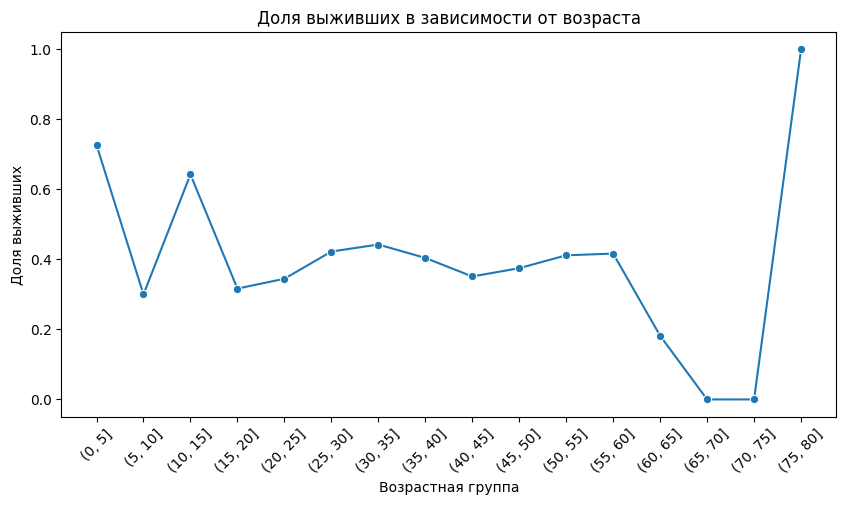

In [145]:
plt.figure(figsize=(10, 5))

sns.lineplot(x=survival_rates.index.astype(str), y=survival_rates.values, marker="o")

plt.xticks(rotation=45)
plt.title("Доля выживших в зависимости от возраста")
plt.xlabel("Возрастная группа")
plt.ylabel("Доля выживших")

plt.show()

Этот график какой-то рандомный, мне кажется, что надо попытаться его сгладить.

In [146]:
age_survival = train_data.groupby("Age")["Survived"].mean()

age_survival_smooth = age_survival.rolling(window=15).mean()

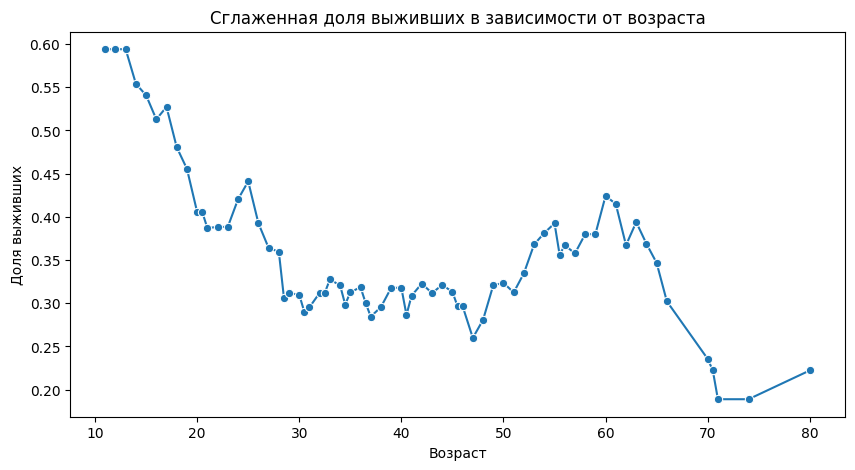

In [147]:
plt.figure(figsize=(10, 5))

sns.lineplot(x=age_survival_smooth.index, y=age_survival_smooth.values, marker="o")

plt.title("Сглаженная доля выживших в зависимости от возраста")
plt.xlabel("Возраст")
plt.ylabel("Доля выживших")

plt.show()

На этом графике более заметна зависимость. В целом есть тенденция убывания. Дети выживали гораздо больше, чем взрослые, но есть скачок в районе 50-70 лет, но не очень сильный.

тенденция убывания. Дети выживали гораздо больше, чем взрослые, но есть скачок в районе 50-70 лет, но не очень сильный.

In [148]:
train_data["FareGroup"] = pd.cut(train_data["Fare"], bins=range(0, 300, 20))

survival_rates = train_data.groupby("FareGroup", observed=True)["Survived"].mean()

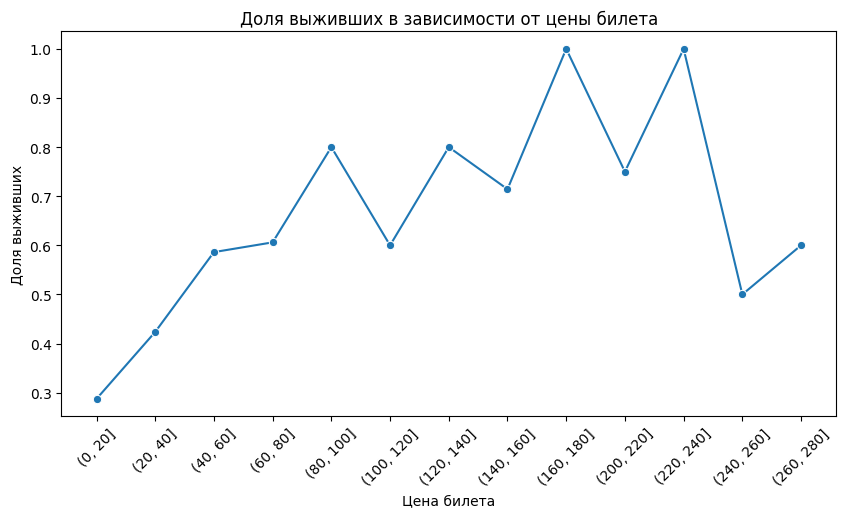

In [149]:
plt.figure(figsize=(10, 5))

sns.lineplot(x=survival_rates.index.astype(str), y=survival_rates.values, marker="o")

plt.xticks(rotation=45)
plt.title("Доля выживших в зависимости от цены билета")
plt.xlabel("Цена билета")
plt.ylabel("Доля выживших")

plt.show()

Есть зависимость для низких цен на билеты (до 100). Она возрастающая. Для более высоких цен нет какой-то зависимости.

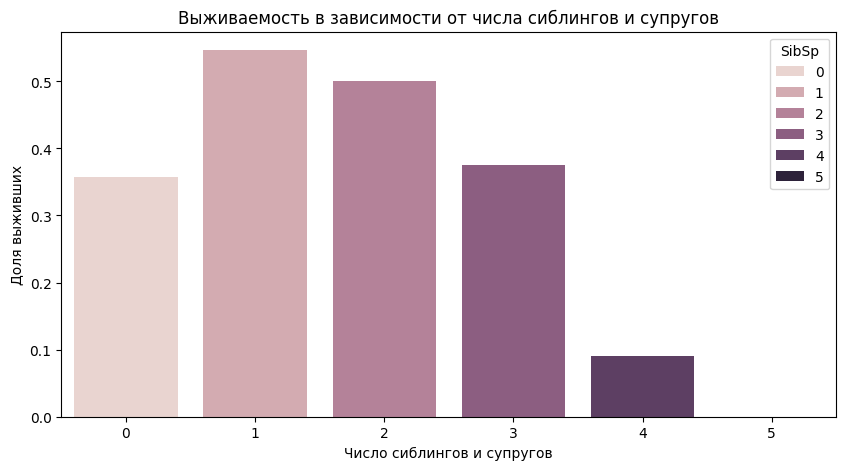

In [150]:
plt.figure(figsize=(10, 5))

sns.barplot(x="SibSp", y="Survived", data=train_data, errorbar=None, hue="SibSp")

plt.title("Выживаемость в зависимости от числа сиблингов и супругов")
plt.xlabel("Число сиблингов и супругов")
plt.ylabel("Доля выживших")

plt.show()

Тут сложно понять, есть ли какие-то зависимости. Когда Sibsp 4 или 5, то выживаемость очень низкая, если 0 или 3, то тоже заметно ниже, чем при 1 или 2. Но найти какую-то общую зависимость мне не удается.

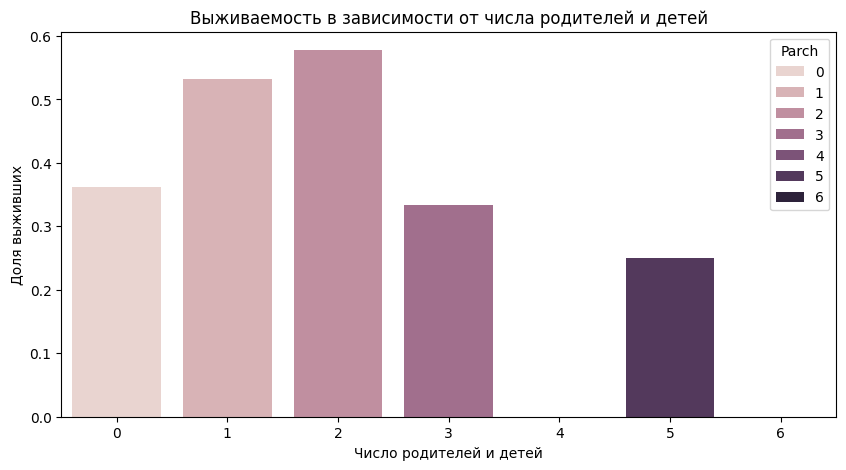

In [151]:
plt.figure(figsize=(10, 5))

sns.barplot(x="Parch", y="Survived", data=train_data, errorbar=None, hue="Parch")

plt.title("Выживаемость в зависимости от числа родителей и детей")
plt.xlabel("Число родителей и детей")
plt.ylabel("Доля выживших")

plt.show()

Тут аналогично с Sibsp, общей зависимости не видно, но при значениях 1 или 2 выживаемость гораздо выше, чем в остальных случаях.

In [152]:
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"]

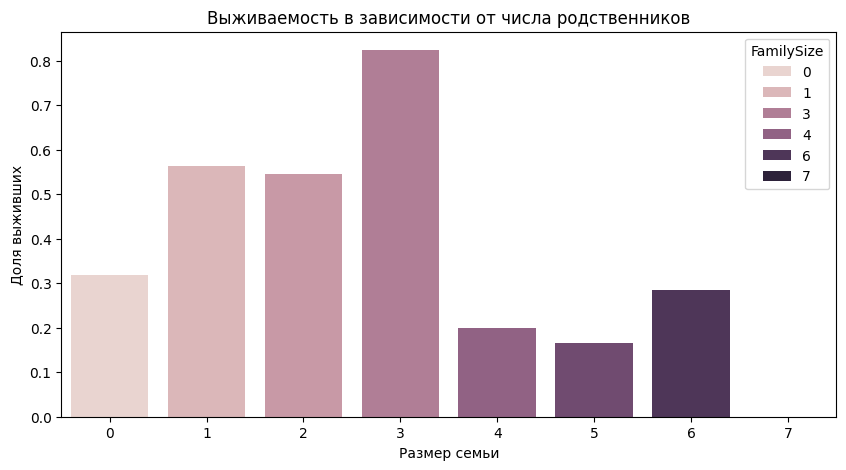

In [153]:
plt.figure(figsize=(10, 5))

sns.barplot(x="FamilySize", y="Survived", data=train_data, errorbar=None, hue="FamilySize")

plt.title("Выживаемость в зависимости от числа родственников")
plt.xlabel("Размер семьи")
plt.ylabel("Доля выживших")

plt.show()

По этому графику можно разделить выборку на три группы по размеру семьи. 0-2 человека, 3 человека, 4-7 человек. Во второй группе выживаемость выше всех, в первой ниже, а в последней ниже всех.

Поделим на группы мужчин и женщин.

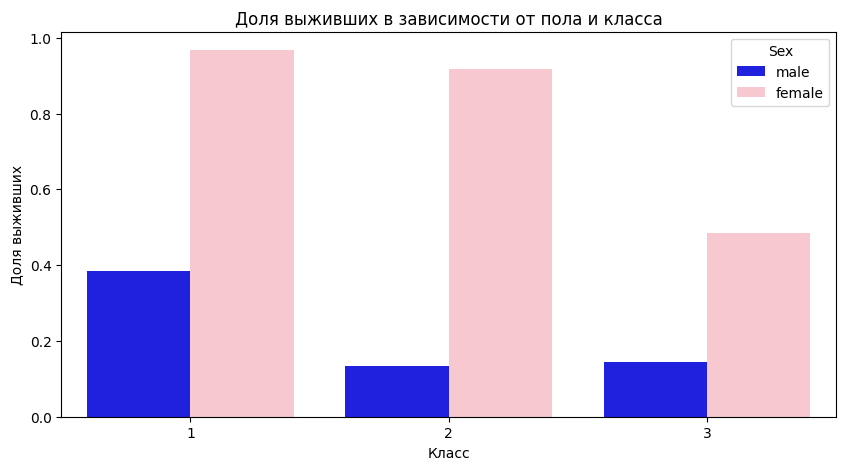

In [154]:
plt.figure(figsize=(10, 5))

sns.barplot(data=train_data, x="Pclass", y="Survived", hue="Sex",  errorbar=None, palette={"male": "blue", "female": "pink"})

plt.title("Доля выживших в зависимости от пола и класса")
plt.xlabel("Класс")
plt.ylabel("Доля выживших")

plt.show()

Для женщин статистика согласуется с общей статистикой по классам, для мужчин выживаемость в первом чуть выше, чем в остальных, но в остальных примерно одинаково. Ну и явно видно, что процент выживших женщин сильно выше чем у мужчин во всех классах.

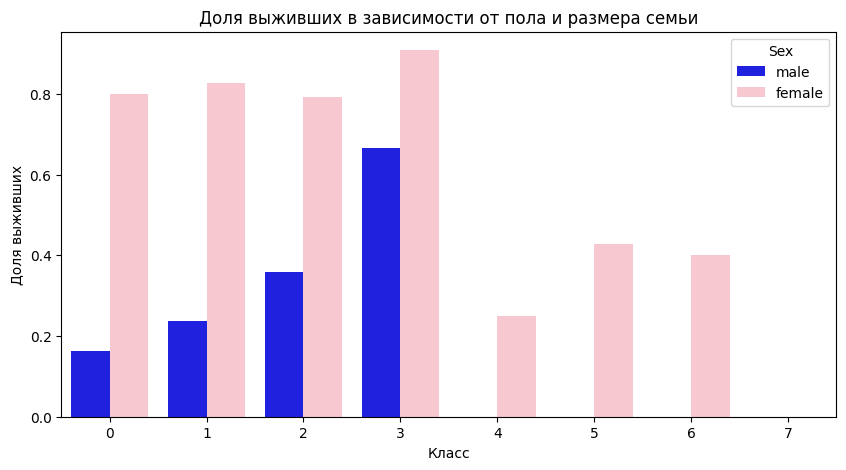

In [155]:
plt.figure(figsize=(10, 5))

sns.barplot(data=train_data, x="FamilySize", y="Survived", hue="Sex",  errorbar=None, palette={"male": "blue", "female": "pink"})

plt.title("Доля выживших в зависимости от пола и paзмера семьи")
plt.xlabel("Класс")
plt.ylabel("Доля выживших")

plt.show()

От четырех членов семьи видно резкое падение для обоих полов, до этого у женщин примерно одинаковая доля выживших, у мужчин возрастающая.

In [156]:
survival_rates = train_data.groupby(["AgeGroup", "Sex"], observed=True)["Survived"].mean().unstack()

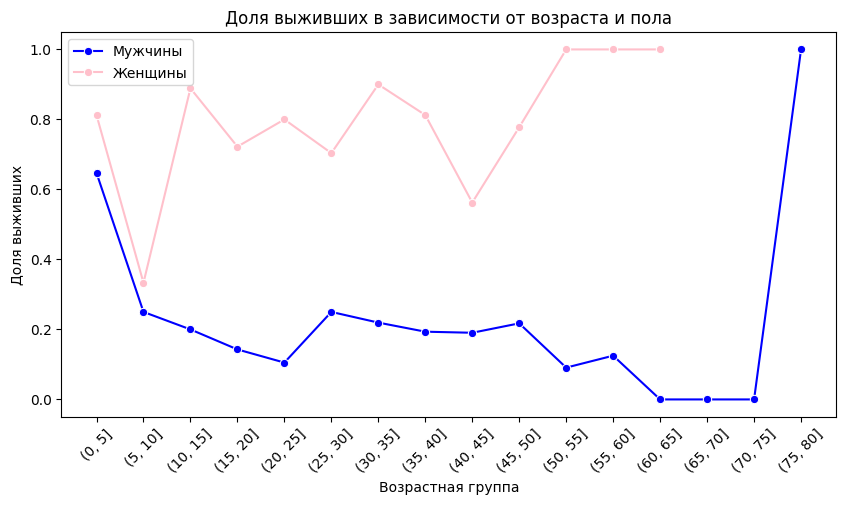

In [157]:
plt.figure(figsize=(10, 5))

sns.lineplot(x=survival_rates.index.astype(str), y=survival_rates["male"], marker="o", label="Мужчины", color="blue")
sns.lineplot(x=survival_rates.index.astype(str), y=survival_rates["female"], marker="o", label="Женщины", color="pink")

plt.xticks(rotation=45)
plt.title("Доля выживших в зависимости от возраста и пола")
plt.xlabel("Возрастная группа")
plt.ylabel("Доля выживших")

plt.legend()
plt.show()

На этом графике не видно никаких зависимостей внутри полов.

In [158]:
survival_rates = train_data.groupby(["FareGroup", "Sex"], observed=True)["Survived"].mean().unstack()

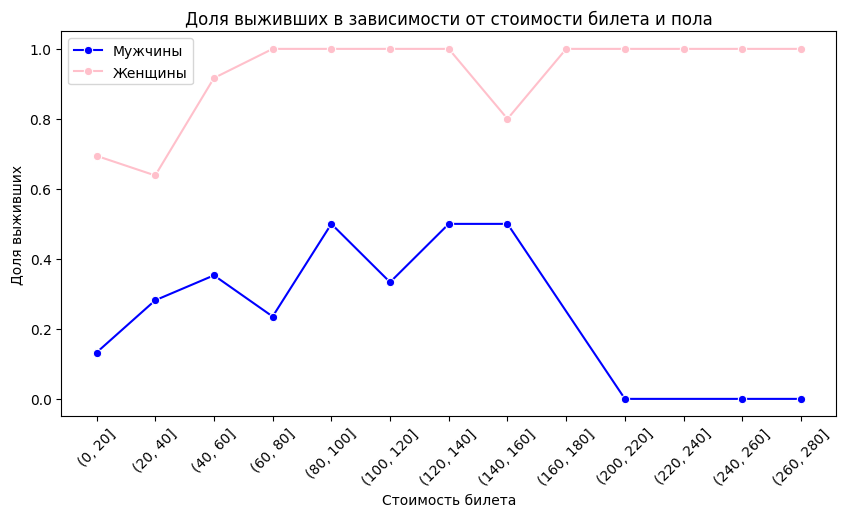

In [159]:
plt.figure(figsize=(10, 5))

sns.lineplot(x=survival_rates.index.astype(str), y=survival_rates["male"], marker="o", label="Мужчины", color="blue")
sns.lineplot(x=survival_rates.index.astype(str), y=survival_rates["female"], marker="o", label="Женщины", color="pink")

plt.xticks(rotation=45)
plt.title("Доля выживших в зависимости от стоимости билета и пола")
plt.xlabel("Стоимость билета")

plt.ylabel("Доля выживших")
plt.legend()
plt.show()

На этом графике тоже внутри полов нет особых зависимостей.

Также на всех графиках видно, что выживаемость женщин сильно выше выживаемости мужчин.


#### 2. Классификация логическими правилами


**Дерево 1:**

                 Пол (Sex)
           ┌───┴────┐
        Женщ.      Мужч.
        [Выжил]     │
                   Возраст (Age)
               ┌────┴─────┐
            ≤ 10 лет    > 10 лет
            [Выжил]     [Не выжил]

Если пассажир женщина → выжил
Если пассажир мужчина и младше 10 лет → выжил
Если пассажир мужчина и старше 10 лет → не выжил

Это дерево я взяла с предпоследнего графика, который показывает зависимость выживания от пола и вораста. Скачок до 1 в конце у мужчин я считаю выбросом (скорее всего там всего 1 или 2 человека). Для всех возрастов большинство женщин выжило, поэтому появилось первое правило. Из мужчин младше 10 лет выжило большинство, поэтому появилось второе правило. Большинство остальных мужчин погибло, поэтому появилось тетье правило.


**Дерево 2:**

                 Класс (Pclass)
           ┌──────┴───────┐
        3 класс         1-2 класс
        [Не выжил]       │
                      Пол (Sex)
                  ┌──────┴───────┐
                 Женщ.        Мужч.
                [Выжила]      [Не выжил]

Если пассажир в 3-м классе → не выжил
Если пассажир в 1-м или 2-м классе и женщина → выжила
Если пассажир в 1-м или 2-м классе и мужчина → не выжил

Это дерево я взяла из гистограммы выживания по классам и гистограммы выживания по полу и классу. На первой из этих гистограмм видно, что большинство пассажиров 3го класса погибли. Поэтому сформулировалось первое правило. Для пассажиров 1го и 2го класса на второй из гистограмм видно, что большинство женщин выжило, а мужчин погибло. Поэтому я сформулировала второе и третье правила.

In [160]:
def tree_1(features: pd.DataFrame) -> pd.Series:

    predicted = pd.Series(0, index=features.index)

    predicted.loc[features["Sex"] == "female"] = 1
    predicted.loc[(features["Sex"] == "male") & (features["Age"] < 10)] = 1

    return predicted

In [161]:
def tree_2(features: pd.DataFrame) -> pd.Series:

    predicted = pd.Series(0, index=features.index)

    predicted.loc[(features["Pclass"] == 1) | (features["Pclass"] == 2) & (features["Sex"] == "female")] = 1

    return predicted

In [162]:
def accuracy(target: pd.Series, predicted: pd.Series) -> float:

    return (target == predicted).astype(float).mean()

In [163]:
y_pred_1 = tree_1(X_test)

acc_1 = accuracy(Y_test, y_pred_1)
print(acc_1) # точность первой модели

0.7674418604651163


In [164]:
y_pred_2 = tree_2(X_test)

acc_2 = accuracy(Y_test, y_pred_2)
print(acc_2) # точность второй модели

0.7627906976744186


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 2bf781f25f8969f7e712ea5d28d608a3 -->
#### 3. Классификация методом ближайшего соседа

В данной части задачи оставим только признаки `'Pclass'`, `'Age'`, `'Sex'`,`'Fare'`.


> Какие могли бы возникнуть проблемы при использовании признаков `'SibSp'`, `'Parch'`? Имеется ли подобная проблема для признака `'Pclass'`?

**Ваш ответ:**
1. Хотя в признаках хранятся инты, размеры семьи нельзя считать числовыми признаками из-за их специфики.
2. Класс тоже нельзя считать числовым признаком. Но у него есть частично логичный порядок, поэтому его можно использовать для методов, но неидеально.

In [165]:
selected_features = ["Pclass", "Age", "Sex", "Fare"]

X_train.loc[:, "Sex"] = X_train["Sex"].map({"male": 0, "female": 1}).fillna(-1).astype(int)
X_test.loc[:, "Sex"] = X_test["Sex"].map({"male": 0, "female": 1}).fillna(-1).astype(int)

In [166]:
X_train = X_train[selected_features]
X_test = X_test[selected_features]

In [167]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, Y_train)

Y_pred_knn = knn.predict(X_test)

acc_knn = accuracy(Y_test, pd.Series(Y_pred_knn, index=Y_test.index))

print(acc_knn) # точность модели

0.6697674418604651


Пока результаты для предыдущего метода лучше.

In [168]:
print("Тренировочные данные")
print(X_train.agg(["min", "max"]))

print("Тестовые данные")
print(X_test.agg(["min", "max"]))

Тренировочные данные
     Pclass    Age  Sex   Fare
min       1   0.67    0    0.0
max       3  80.00    1  263.0
Тестовые данные
     Pclass    Age  Sex      Fare
min       1   0.42    0    0.0000
max       3  71.00    1  512.3292


Как мы видим данные в каждом столбце распределены очень по-разному.

> Как это может повлиять на работу kNN, почему?

**Ваш ответ:**  Этот метод очень чувствительный к расстояниям. То есть fare будет влять очень сильно, а пол очень слабо. Особенно учитывая, что в стандартной метрикой используется квадрат. Ну то есть fare может в сумму изначально добавить до ~250.000, а пол только 0 или 1. Получается в этом пол не значит почти ничего.

Для решения этой проблемы нужно привести признаки к единому масштабу. Существует много методов масштабирования рассмотрим работу одного из них — минимаксная нормализация.

> В чем может быть недостаток такого метода масштабирования?

**Ваш ответ:** Для некоторых признаков минимальное/максимальное значение может быть очень далеко от среднех. Например (в этом датасете может быть вообще не так) fare равен 0 у 10%, 10 у 89% и 1000 у 1%. Тогда fare будет влиять довольно мало в сренем, потому что после преобразования у 99% данных новое значение будет почти нулевое.


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 3cf8b0b6b0402c9ceb439c2de6ee4276 -->


Отмасштабируйте данные

In [ ]:
X_combined = pd.concat([X_train[selected_features], X_test[selected_features]]) # я попробовала взять минимум и максимум только по тренировочной выборке, но получилось очень некрасиво

In [170]:
scaler = MinMaxScaler()

scaler.fit(X_combined)

X_train_scaled = scaler.transform(X_train[selected_features])
X_test_scaled = scaler.transform(X_test[selected_features])

In [171]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train[selected_features].columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test[selected_features].columns)

In [172]:
print("Тренировочные данные")
print(X_train_scaled.agg(["min", "max"]))

print("Тестовые данные")
print(X_test_scaled.agg(["min", "max"]))

Тренировочные данные
     Pclass       Age  Sex      Fare
min     0.0  0.003141  0.0  0.000000
max     1.0  1.000000  1.0  0.513342
Тестовые данные
     Pclass       Age  Sex  Fare
min     0.0  0.000000  0.0   0.0
max     1.0  0.886906  1.0   1.0


Обучите модель и сравните результат предсказаний со стандартизацией и без.

In [173]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, Y_train)

Y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy(Y_test, pd.Series(Y_pred_knn, index=Y_test.index))

print(acc_knn) # точность модели

0.7581395348837209


Точность без стандартизации 0.67, с - 0.76. Получается со стандартизацией лучше)).

**Вывод:** 
1. kNN очень чувствителен к масштабу данных. Как я писала выше, если разные признаки имеют разные масштабы, то они будут очень по-разному влиять на выбор ближайшего соседа. Поэтому имеет смысл использовать нормализацию перед тем как использовать метод ближайшего соседа.
2. Ещё могут быть проблемы, если признак распределен очень неравномерно между минимумом и максимумом. Я тоже приводила выше пример, когда признак может не влиять почти в результате или наоборот, если в выборке по какому-то из признаков выбросы сильно далеко от большинства.

**А можем ли мы как-то еще повысить точность модели?**

Постройте график зависимости точности (`accuracy_score`) от значения $k$ (от 1 до 20) для обучающей и тестовой выборок.

In [174]:
ks = range(1, 21)
accuracies_test_l2 = []
accuracies_train_l2 = []

for k in range (1, 21):
    model = KNeighborsClassifier(n_neighbors=k, algorithm="brute")
    model.fit(X_train_scaled, Y_train)

    Y_pred_test = model.predict(X_test_scaled)
    Y_pred_train = model.predict(X_train_scaled)

    score_test = accuracy_score(Y_test, Y_pred_test)
    score_train = accuracy_score(Y_train, Y_pred_train)

    accuracies_test_l2.append(score_test)
    accuracies_train_l2.append(score_train)

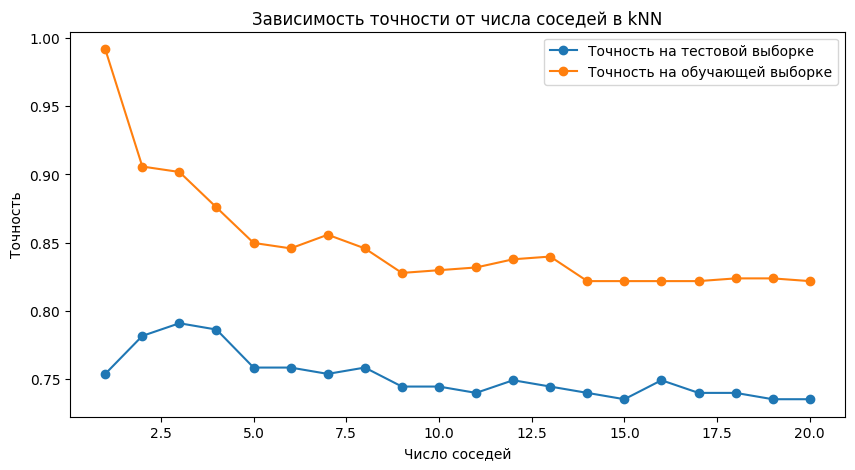

In [175]:
plt.figure(figsize=(10, 5))

plt.plot(ks, accuracies_test_l2, label="Точность на тестовой выборке", marker="o")
plt.plot(ks, accuracies_train_l2, label="Точность на обучающей выборке", marker="o")

plt.xlabel("Число соседей")
plt.ylabel("Точность")
plt.title("Зависимость точности от числа соседей в kNN")

plt.legend()
plt.show()

**Вывод:**
1. Для k=1 для тестовой выборки ближайший сосед - он сам. Тогда точность 100%.
2. Для тестовой выборки на k до 3 наблюдается рост, а потом медленное убывание. Для обучающей выборке в целом есть тенденция на убывание. Нет роста на маленьких k, потому что для обучающей выборки для маленьких k очень сильно влияет сам объект.
3. На обеих выборках есть некая "стабилизация" для бОльших k, но все равно есть некое убывание.
Для данной задачи стоит выбрать k от 2 до 4. Если взять k больше то точность упадет.